In [5]:
import superstats as sup
import numpy as np
from numba import njit

## Constants

In [6]:
NUM_STEPS = 480
NUM_SAMPLES = 1000

## Context

In [104]:
def generate_context(num_steps):
    conditions = [
        (0.5, 0.5),   # high difficulty, high reward
        (0.5, -0.5),  # high difficulty, low reward
        (-0.5, 0.5),  # low difficulty, high reward
        (-0.5, -0.5), # low difficulty, low reward
    ]
    num_blocks = (num_steps + 59) // 60
    conditions = (conditions * ((num_blocks + len(conditions) - 1) // len(conditions)))[:num_blocks]
    np.random.shuffle(conditions)
    difficulty = []
    reward = []
    remaining_steps = num_steps
    for difficulty_code, reward_code in conditions:
        block_steps = min(60, remaining_steps)
        difficulty.extend([difficulty_code] * block_steps)
        reward.extend([reward_code] * block_steps)
        remaining_steps -= block_steps
    return {
        "difficulty": difficulty,
        "reward": reward,
    }

In [105]:
context = sup.ContextSimulator(
    simulator=generate_context,
    is_batched=False
)

## Prior

In [106]:
formula = sup.Formula([
    "v = v_0 + b_v_1 * difficulty + b_v_2 * reward + b_v_3 * difficulty * reward",
    "a = a_0 + b_a_1 * difficulty + b_a_2 * reward + b_a_3 * difficulty * reward",
    "tau = tau_0 + b_tau_1 * difficulty + b_tau_2 * reward + b_tau_3 * difficulty * reward",
])

prior = sup.JointPrior(
    v_0=sup.transition.RandomWalk(
        bounds=(0.0, 8.0),
        initial_prior=sup.Prior("normal", loc=-1.0, scale=1.0),
        sigma=sup.Prior("halfnormal", scale=0.15),
    ),
    b_v_1=sup.Prior("normal", loc=0.0, scale=2.0),
    b_v_2=sup.Prior("normal", loc=0.0, scale=2.0),
    b_v_3=sup.Prior("normal", loc=0.0, scale=2.0),
    a_0=sup.transition.RandomWalk(
        bounds=(0.0, 6.0),
        initial_prior=sup.Prior("normal", loc=-1.0, scale=1.0),
        sigma=sup.Prior("halfnormal", scale=0.15),
    ),
    b_a_1=sup.Prior("normal", loc=0.0, scale=2.0),
    b_a_2=sup.Prior("normal", loc=0.0, scale=2.0),
    b_a_3=sup.Prior("normal", loc=0.0, scale=2.0),
    tau_0=sup.transition.RandomWalk(
        bounds=(0.0, 1.0),
        initial_prior=sup.Prior("normal", loc=0.0, scale=0.75),
        sigma=sup.Prior("halfnormal", scale=0.075),
    ),
    b_tau_1=sup.Prior("normal", loc=0.0, scale=0.5),
    b_tau_2=sup.Prior("normal", loc=0.0, scale=0.5),
    b_tau_3=sup.Prior("normal", loc=0.0, scale=0.5),
    bias=0.5
)

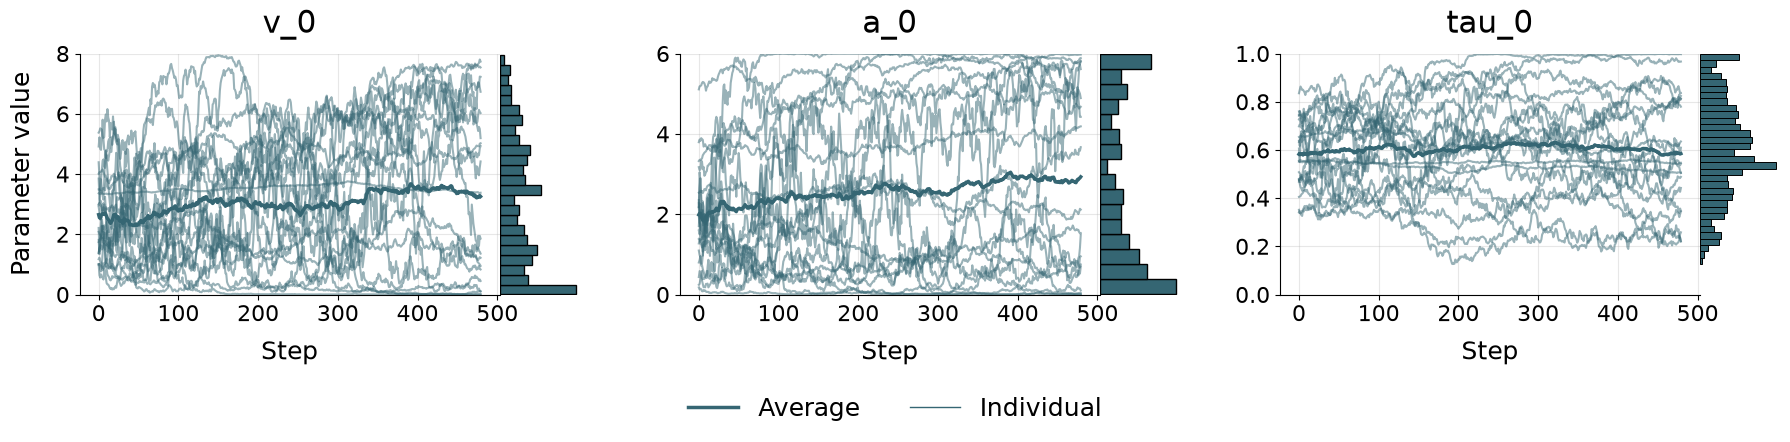

In [107]:
fig=prior.plot_time_varying_prior(num_steps=NUM_STEPS,num_trajectories=20)

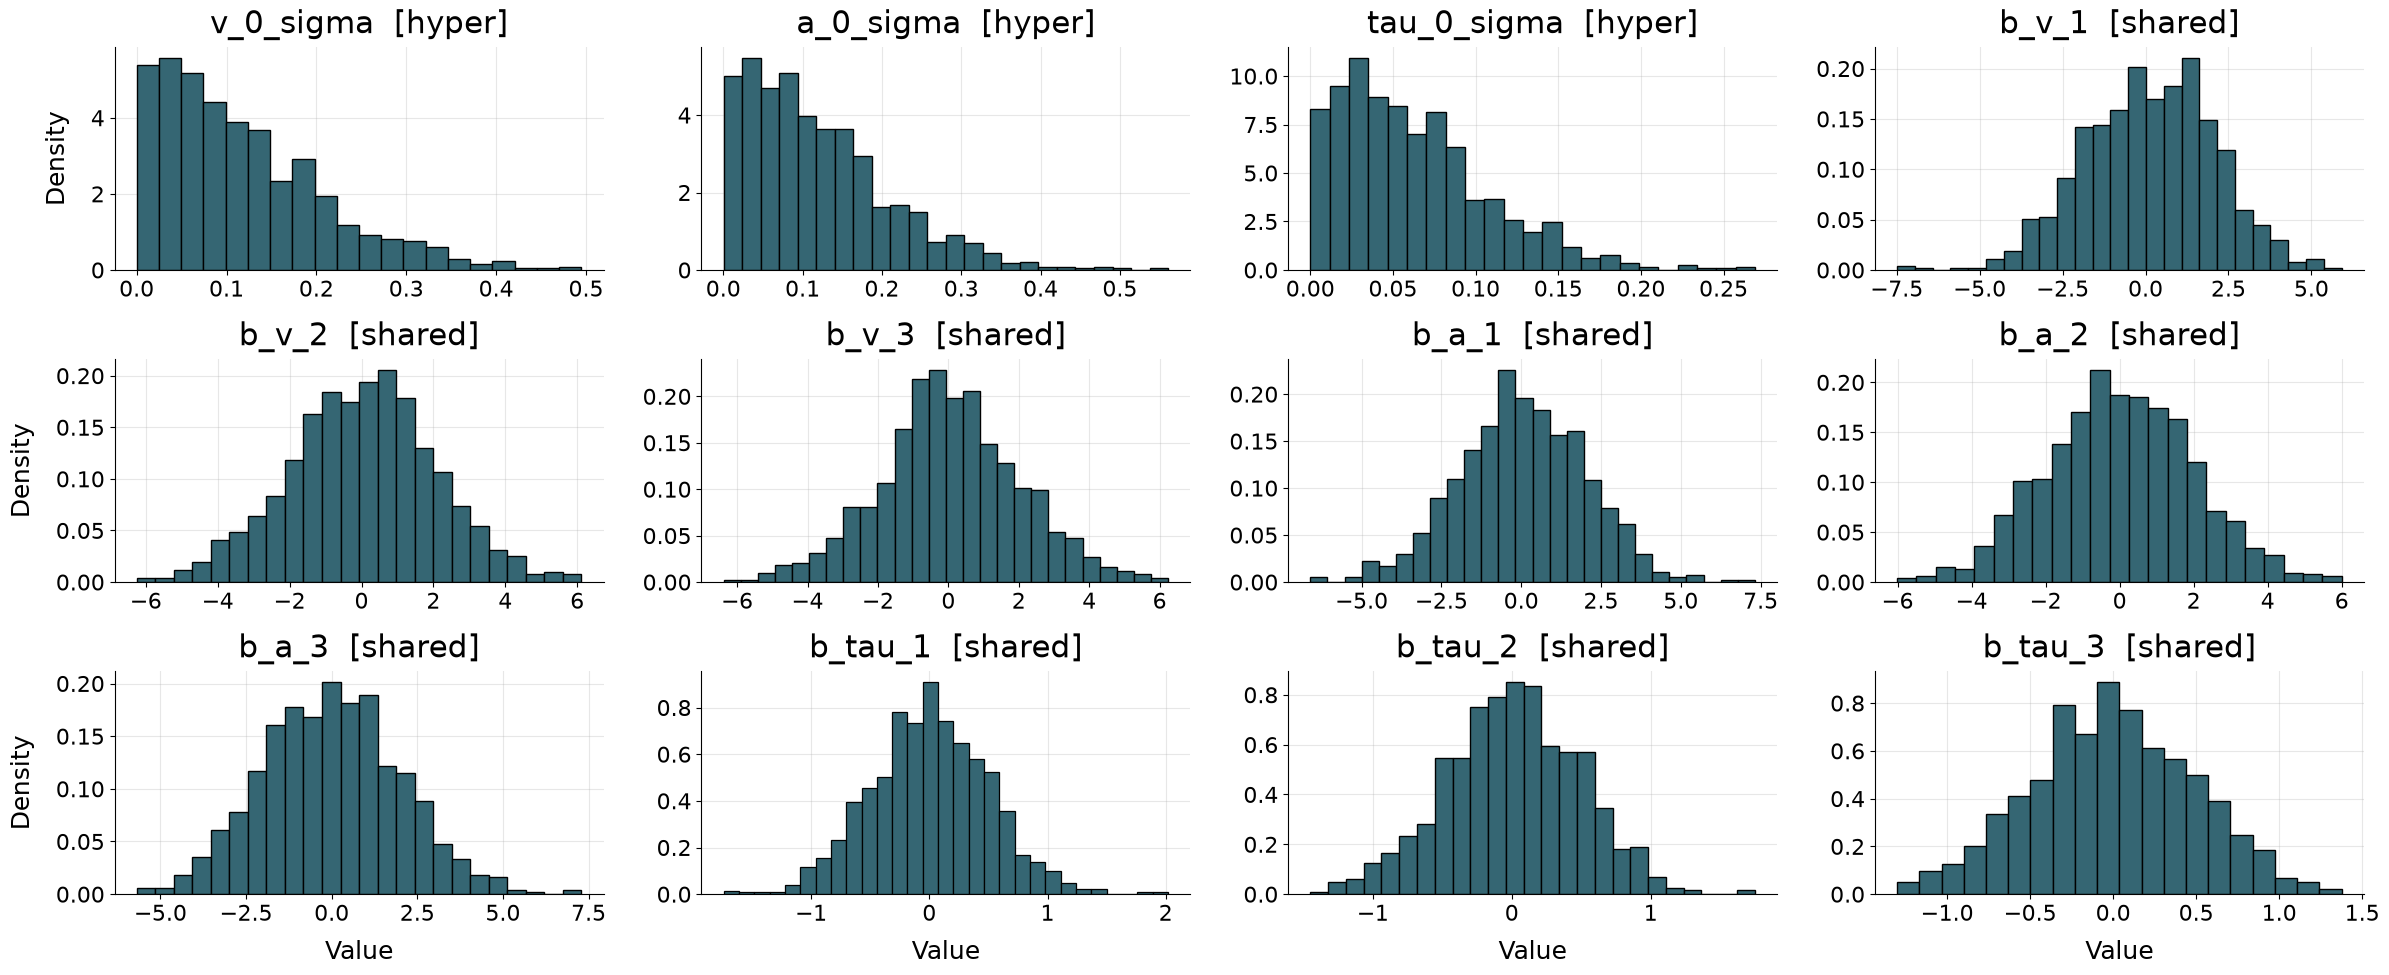

In [108]:
fig=prior.plot_time_invariant_prior()

In [117]:
missing_process = sup.simulation.RandomMissingProcess(
    p_missing=sup.Prior("beta", a=1.5, b=15.0),
    missing_value=-1,
)

model = sup.Model(
    prior=prior,
    simulator=sup.simulation.sample_ddm,
    missing=missing_process,
    context=context,
    context_mapping=sup.ContextMapping(formula_context=("difficulty", "reward")),
    formula=formula,
)

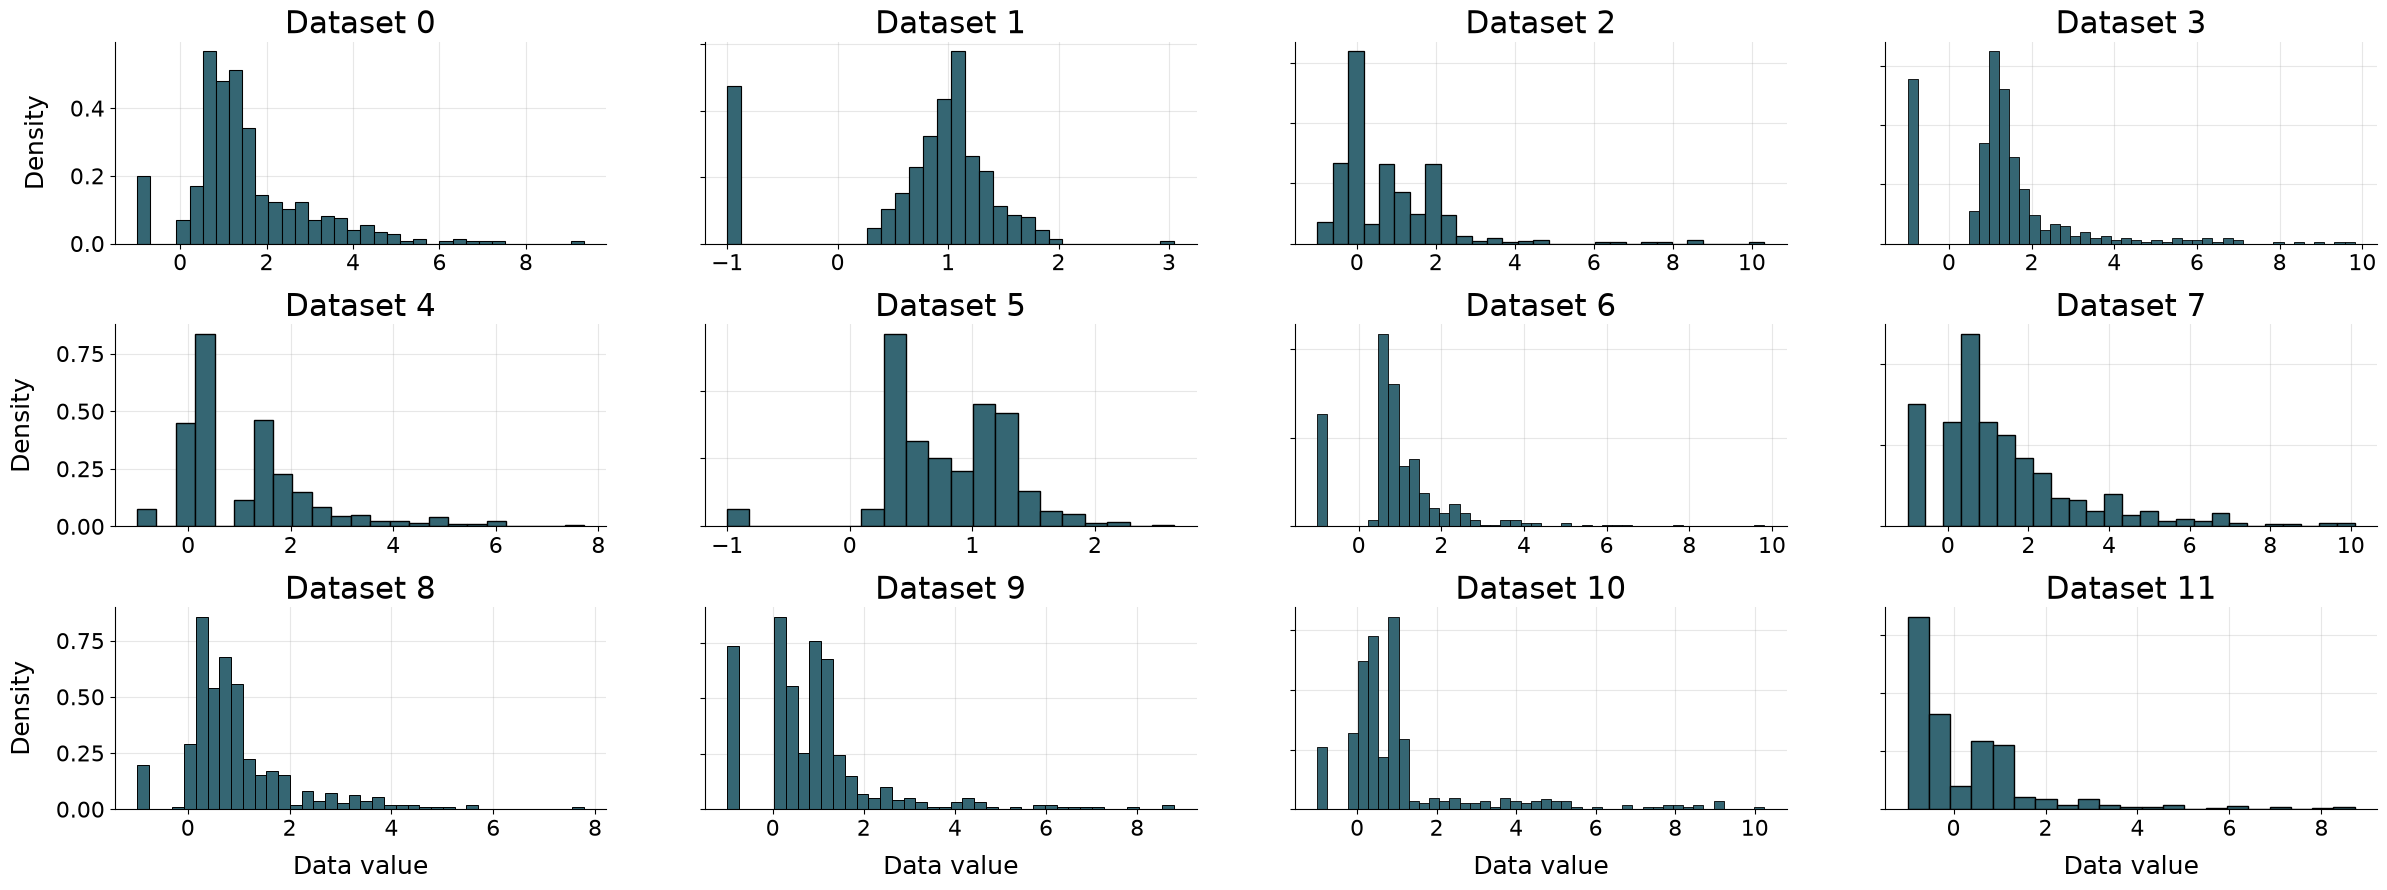

In [119]:
fig = model.plot_push_forward(
    batch_size=12,
    num_steps=NUM_STEPS,
    data_dim=0,
    kind="dist"
)

## Approximator

In [120]:
workflow = sup.Workflow(
    model=model,
    checkpoint_filepath="checkpoints/ms_study_ddm_regressors"
)

In [ ]:
history = workflow.fit_online(
    num_steps=NUM_STEPS,
    epochs=100,
    num_batches_per_epoch=1000,
    batch_size=32
)